First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  


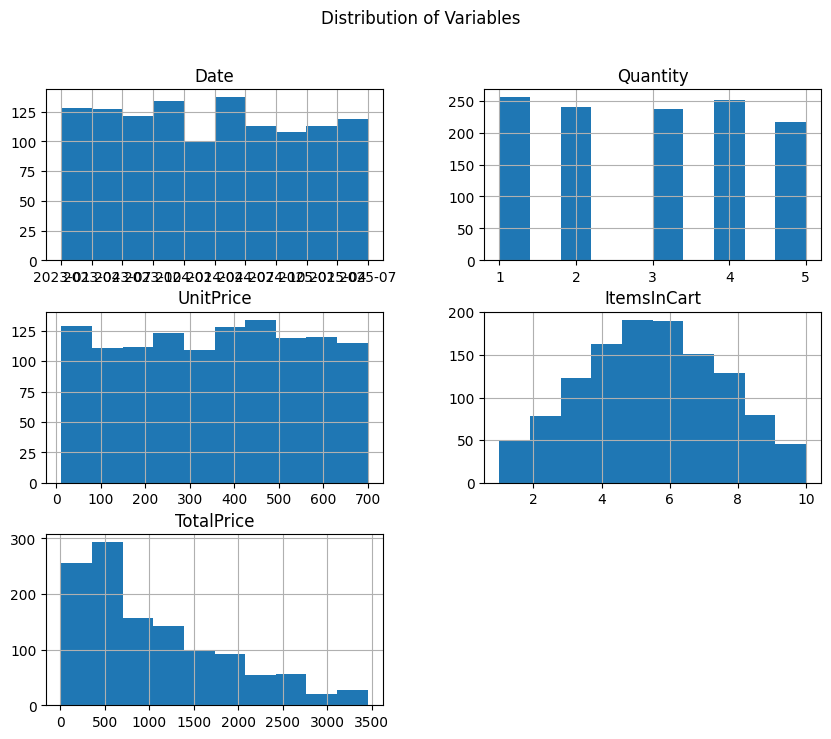

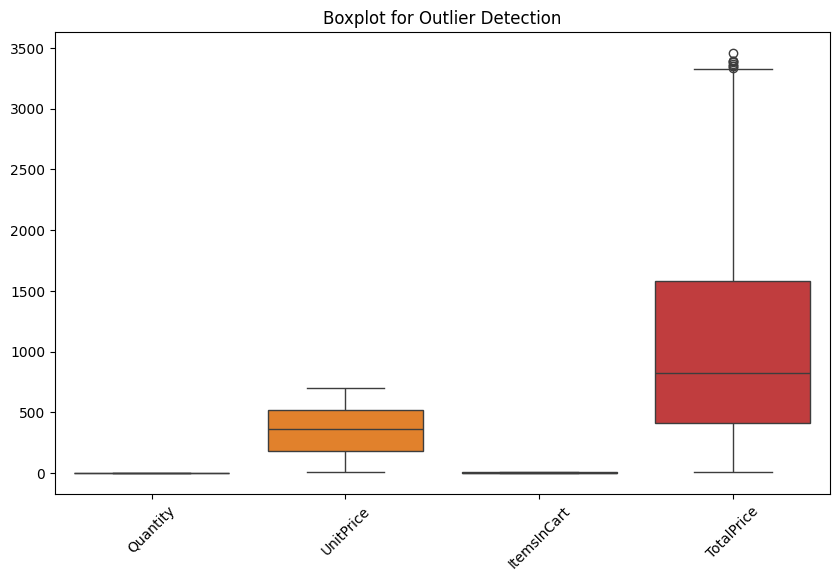

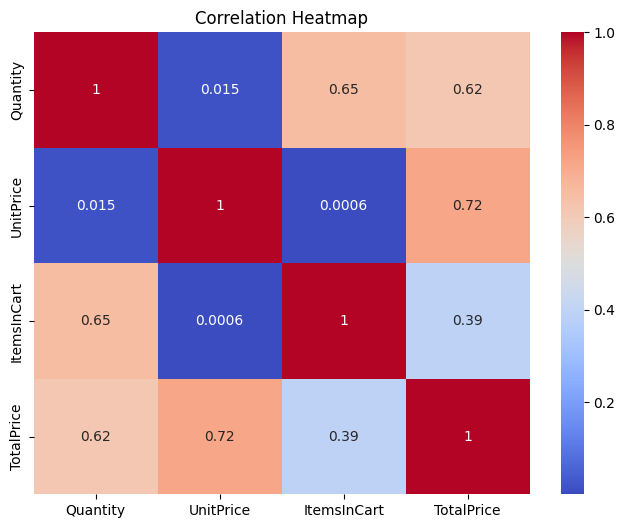


Outliers Detection:
Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


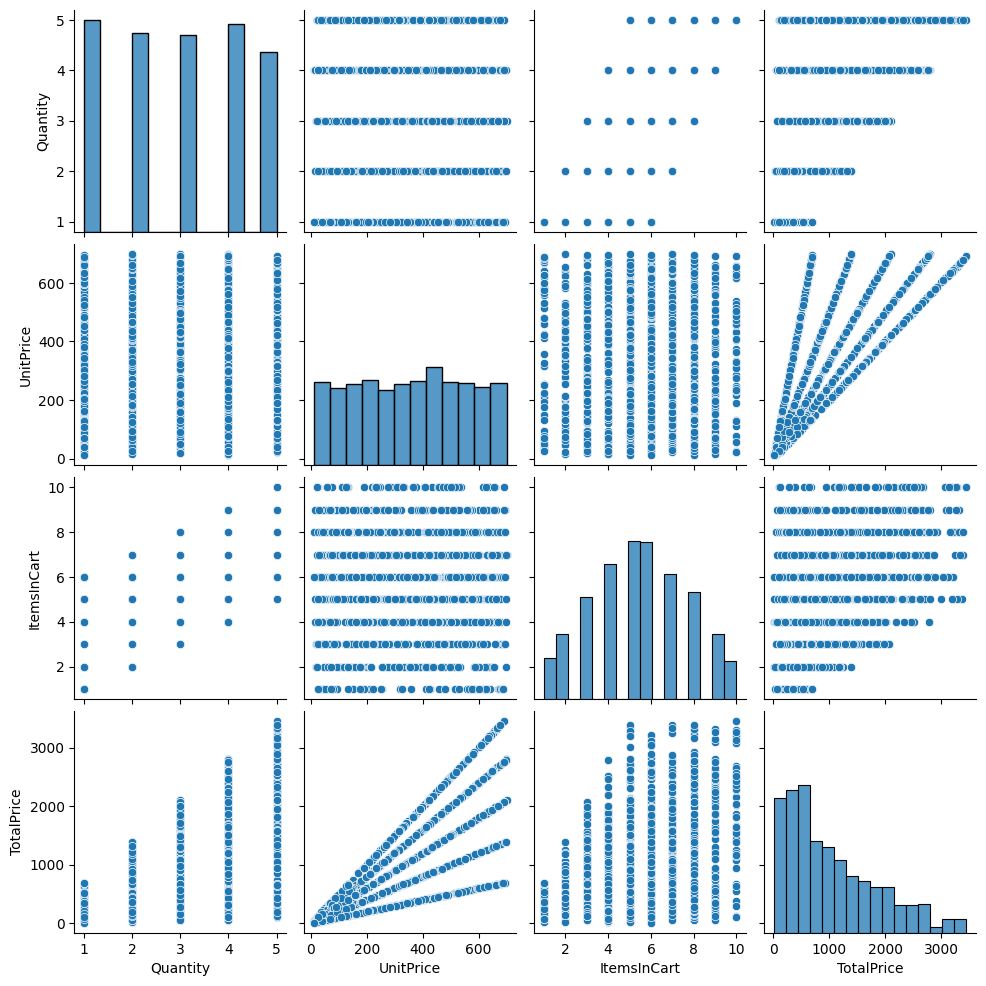


Summary Observations:
- Check distributions using histograms.
- Use boxplots to identify outliers.
- Heatmap shows relationships between variables.
- High correlation means strong relationship.
- Missing values should be handled if present.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update file path if needed)
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Decodelabs/Dataset for Data Analytics2.xlsx')

# Display first rows
print("First 5 rows:")
print(df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# BASIC STATISTICS
# -----------------------------
print("\nBasic Statistics:")
print(df.describe())

# Mean, Median, Count
print("\nMean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nCount:\n", df.count())

# -----------------------------
# DATA VISUALIZATION
# -----------------------------

# Histogram for all numeric columns
df.hist(figsize=(10,8))
plt.suptitle("Distribution of Variables")
plt.show()

# Boxplot (to detect outliers)
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# OUTLIER DETECTION (IQR METHOD)
# -----------------------------
print("\nOutliers Detection:")

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

# -----------------------------
# TREND ANALYSIS
# -----------------------------

# Pairplot (relationships)
sns.pairplot(df)
plt.show()

# If dataset has time column (optional)
# df['Date'] = pd.to_datetime(df['Date'])
# df.groupby('Date').mean().plot(figsize=(10,6))

# -----------------------------
# SUMMARY OBSERVATIONS
# -----------------------------
print("\nSummary Observations:")

print("- Check distributions using histograms.")
print("- Use boxplots to identify outliers.")
print("- Heatmap shows relationships between variables.")
print("- High correlation means strong relationship.")
print("- Missing values should be handled if present.")